# 🏠 机器学习实战：房价预测回归 (Regression Challenge)

## 🎯 目标
这是一个经典的 **回归 (Regression)** 任务。
你的目标是：根据房屋的特征（面积、房龄、学区评分等），预测其 **最终售价 (Price)**。

**要求**：
1.  **少提示**：除了必要的步骤说明，我会尽量少给代码提示。
2.  **全流程**：从 EDA 到 模型评估，请你独立完成。
3.  **对比模型**：尝试至少两种模型（例如 线性回归 vs 随机森林/XGBoost），看看谁更准。

## 📚 函数加油站 (Cheat Sheet)

| 场景 | 核心函数 | 备注 |
| :--- | :--- | :--- |
| **看相关性** | `df.corr()`, `sns.heatmap()` | 找找谁跟Price关系最大？ |
| **散点图** | `sns.scatterplot(x, y)` | 看看是不是线性关系？ |
| **线性回归** | `from sklearn.linear_model import LinearRegression` | 简单直观的 Baseline |
| **树模型** | `from sklearn.ensemble import RandomForestRegressor` | 能捕捉非线性关系 |
| **评估指标** | `mean_absolute_error`, `r2_score` | 误差越小越好，R2越接近1越好 |

In [18]:
# 0. 导入工具包
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# 忽略警告
import warnings
warnings.filterwarnings('ignore')

## 🧩 1. 数据生成 (Data Gen)
*运行此格生成模拟的城市住房数据。*

In [2]:
np.random.seed(2026)
n_samples = 3000

# 特征生成
data = {
    'size_sqft': np.random.normal(1200, 400, n_samples).clip(300, 3000), # 房屋面积
    'bedrooms': np.random.randint(1, 6, n_samples), # 卧室数量 
    'age': np.random.randint(0, 50, n_samples),     # 房龄
    'dist_to_center': np.random.uniform(0.5, 20, n_samples), # 距离市中心(km)
    'school_score': np.random.randint(1, 11, n_samples),     # 学区评分(1-10)
    'has_pool': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]) # 有无泳池
}

df = pd.DataFrame(data)

# 构造目标变量 Price (万元)
# 逻辑：面积越大越贵，离市中心越近越贵，学区越好越贵，即使是老房子在好地段也贵
base_price = 200 + (df['size_sqft'] * 0.5) - (df['dist_to_center'] * 15) + (df['school_score'] * 30)
base_price = base_price + (df['bedrooms'] * 20) - (df['age'] * 2)
base_price = base_price + (df['has_pool'] * 50)

# 加入一些随机噪声和非线性因素 (让线性回归稍微难受一点)
df['price'] = base_price + np.random.normal(0, 50, n_samples)
df['price'] = df['price'].clip(100, None) # 房价最低100万

print(f"数据生成完毕! 形状: {df.shape}")
df.head()

数据生成完毕! 形状: (3000, 7)


,size_sqft,bedrooms,age,dist_to_center,school_score,has_pool,price
0,1027.312592,2,39,19.337601,3,1,501.155559
1,642.850413,1,43,18.664037,3,0,362.518077
2,1324.628267,2,6,2.092366,3,0,1000.684668
3,1194.706048,4,24,14.247161,9,0,839.830909
4,1779.883091,1,14,2.462531,4,0,1247.659245


---

In [3]:
print(df.isnull().sum())

size_sqft         0
bedrooms          0
age               0
dist_to_center    0
school_score      0
has_pool          0
price             0
dtype: int64


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   size_sqft       3000 non-null   float64
 1   bedrooms        3000 non-null   int64  
 2   age             3000 non-null   int64  
 3   dist_to_center  3000 non-null   float64
 4   school_score    3000 non-null   int64  
 5   has_pool        3000 non-null   int64  
 6   price           3000 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 164.2 KB
None


In [5]:
print(df.describe(include='all'))

         size_sqft     bedrooms          age  dist_to_center  school_score  \
count  3000.000000  3000.000000  3000.000000     3000.000000   3000.000000   
mean   1218.470203     2.989333    24.802000       10.137302      5.492667   
std     404.932794     1.418411    14.549021        5.632162      2.892992   
min     300.000000     1.000000     0.000000        0.502602      1.000000   
25%     947.456333     2.000000    12.000000        5.334882      3.000000   
50%    1213.311075     3.000000    25.000000       10.028369      5.000000   
75%    1493.367241     4.000000    38.000000       14.948360      8.000000   
max    2643.997208     5.000000    49.000000       19.997069     10.000000   

          has_pool        price  
count  3000.000000  3000.000000  
mean      0.213667   843.173602  
std       0.409962   248.634549  
min       0.000000   100.000000  
25%       0.000000   673.874152  
50%       0.000000   841.837203  
75%       0.000000  1014.877821  
max       1.000000  1646.

## ⚔️ 挑战 1: EDA 与 业务直觉

**思考**: 买房子时，你觉得哪个因素最影响房价？

**任务**:
1.  画出相关性热力图 (`heatmap`)，验证你的猜想。
2.  画出 `dist_to_center` (X轴) 和 `price` (Y轴) 的散点图，看看是什么趋势？

<Axes: >

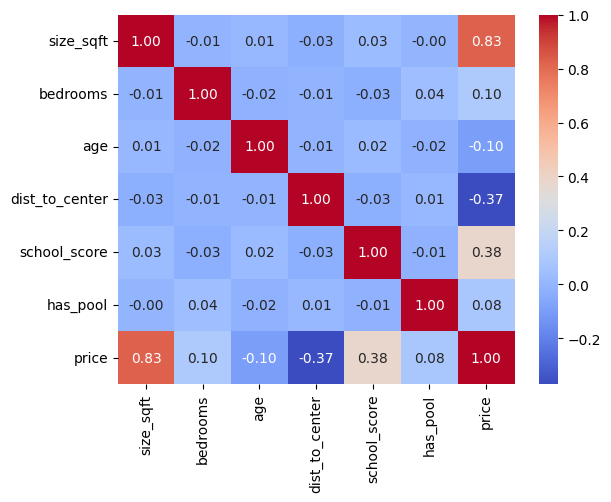

In [6]:
# TODO: 你的 EDA 代码
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='.2f')

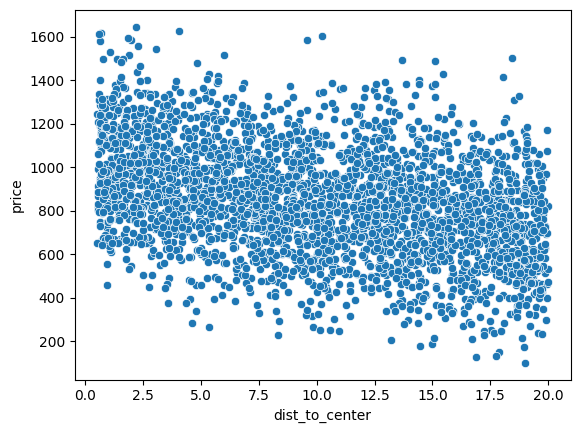

In [7]:
sns.scatterplot(data=df,x='dist_to_center',y='price')
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols_to_scale = df.drop(columns=['has_pool']).columns

# 只改变选中的列
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

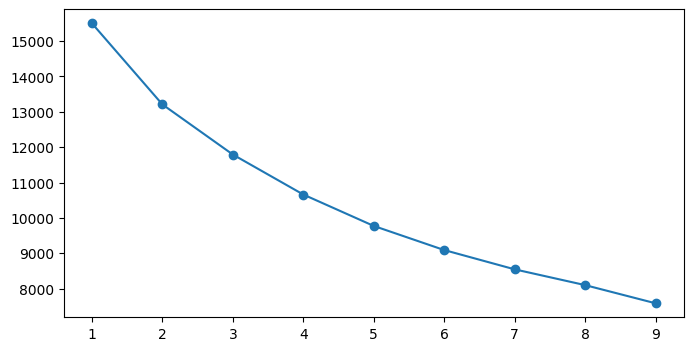

In [9]:
# 尝试下聚类，看看不同房子之间和价格的关系是啥样，有没有一些特征？
from sklearn.cluster import KMeans
df_processed = df.drop(columns=['price'])
sse = []
k_range = range(1, 10)

plt.figure(figsize=(8, 4)) # 设置画布大小

for k in k_range:
    # n_init=10 是为了显示指定初始点尝试次数，避免警告
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_processed)
    sse.append(kmeans.inertia_) # inertia_ 就是 SSE

plt.plot(k_range, sse, marker='o')


In [10]:
# 💡 你的代码：使用轮廓系数辅助判断
from sklearn.metrics import silhouette_score

k_candidates = [2, 3, 4, 5, 6]

for k in k_candidates:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_processed)
    score = silhouette_score(df_processed, kmeans.labels_)
    print(f"K={k} 的轮廓系数: {score:.4f}")

kmeans = KMeans(n_clusters=3,random_state=42)
df['cluster'] = kmeans.fit_predict(df_processed)

print(df.groupby('cluster').mean())

K=2 的轮廓系数: 0.1464
K=3 的轮廓系数: 0.1349
K=4 的轮廓系数: 0.1461
K=5 的轮廓系数: 0.1491
K=6 的轮廓系数: 0.1493
         size_sqft  bedrooms       age  dist_to_center  school_score  \
cluster                                                                
0         0.051882 -1.037718  0.107073        0.120597      0.088965   
1         0.068150  0.562840  0.092678       -0.940118      0.107593   
2        -0.141112  0.701549 -0.238401        0.881733     -0.231769   

         has_pool     price  
cluster                      
0        0.205830 -0.096678  
1        0.207354  0.460486  
2        0.230596 -0.384000  


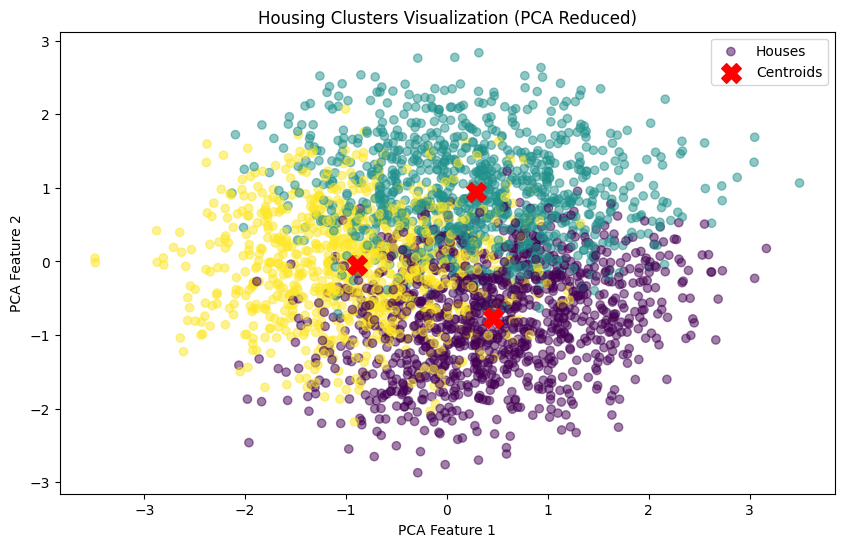

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. 训练 K-Means (假设手肘法告诉你 K=3 最合适，你可以改)
kmeans.fit(df_processed)  # 注意：这里 df 是标准化后的数据
y_kmeans = kmeans.predict(df_processed)
centers = kmeans.cluster_centers_ # 拿到 13 维的中心点

# 2. PCA 降维 (把 13 维 -> 2 维)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_processed)       # 房子数据的降维结果
centers_pca = pca.transform(centers) # 中心点的降维结果 (为了画在同一张图上)

# 3. 可视化
plt.figure(figsize=(10, 6))

# 画散点 (房子)，颜色由 y_kmeans 决定
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', alpha=0.5, label='Houses')

# 画中心 (Centroids) - 红色的 X
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title('Housing Clusters Visualization (PCA Reduced)')
plt.xlabel('PCA Feature 1')
plt.ylabel('PCA Feature 2')
plt.legend()
plt.show()

---

## ⚔️ 挑战 2: 切分数据 (Train/Test Split)

**任务**:
1.  定义 `X` (特征) 和 `y` (目标 `price`)。
2.  拆分训练集和测试集 (80% / 20%)，设置 `random_state=42`。

In [12]:
df=pd.get_dummies(df,columns=['cluster'])
df

,size_sqft,bedrooms,age,dist_to_center,school_score,has_pool,price,cluster_0,cluster_1,cluster_2
0,-0.472151,-0.697610,0.976036,1.633801,-0.861766,1,-1.375815,True,False,False
1,-1.421756,-1.402742,1.251014,1.514189,-0.861766,0,-1.933503,True,False,False
2,0.262206,-0.697610,-1.292536,-1.428630,-0.861766,0,0.633610,False,True,False
3,-0.058696,0.712653,-0.055133,0.729834,1.212557,0,-0.013446,False,False,True
4,1.386666,-1.402742,-0.742579,-1.362896,-0.516046,0,1.627099,True,False,False
...,...,...,...,...,...,...,...,...,...,...
2995,-0.646625,-0.697610,-0.398856,-0.551439,1.558278,1,0.136095,True,False,False
2996,-0.972455,0.712653,0.013611,1.296045,1.212557,0,-0.438909,False,False,True
2997,0.877855,1.417785,0.838547,0.297670,-0.170325,1,0.975964,False,False,True
2998,2.233494,0.712653,-0.880068,0.108120,-0.516046,0,1.527347,False,False,True


In [13]:
# TODO: 定义 X, y 并切分
# 1. 准备好数据
x = df.drop(columns=['price','cluster_0','cluster_1','cluster_2'])
y_reg = df['price']
y_clf = df[['cluster_0','cluster_1','cluster_2']]

# 2. 一次性切分 (One-time split)
# python会自动解包返回的6个部分
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    x, y_reg, y_clf, 
    test_size=0.2, 
    random_state=42
)

# 3. 验证形状
print("X 训练集:", X_train.shape)
print("y_reg 训练集:", y_reg_train.shape) # 行数应该和 X_train 一致
print("y_clf 训练集:", y_clf_train.shape) # 行数也应该和 X_train 一致

X 训练集: (2400, 6)
y_reg 训练集: (2400,)
y_clf 训练集: (2400, 3)


---

## ⚔️ 挑战 3: 线性回归 vs 高阶模型

**任务**:
1.  先用最简单的 `LinearRegression` 训练并预测，看看 M[目标业务] (平均误差) 是多少？
2.  再用 `RandomForestRegressor` 或 `XGBRegressor` 试试，误差能降低吗？

In [15]:
# TODO: 模型训练与评估
model_linear = LinearRegression()

model_linear.fit(X_train,y_reg_train)

linear_y_pred = model_linear.predict(X_test)
# 4. 评估
print(f"Baseline M[目标业务]: {mean_absolute_error(y_reg_test, linear_y_pred):.4f}")
print(f"Baseline R2: {r2_score(y_reg_test, linear_y_pred):.4f}")


Baseline M[目标业务]: 0.1489
Baseline R2: 0.9645


In [17]:
# 1. 拼积木：把 Cluster 标签拼回 X
# 注意：我们要保留原始的 X_train 不变，创建一个新的副本，防止污染
X_train_enhanced = X_train.copy()
X_test_enhanced = X_test.copy()

# 把 y_clf (聚类结果) 作为新的一列加进去
# 1. 拼积木：把 Cluster 标签拼回 X
# 使用 pd.concat 横向拼接 (axis=1)
# 注意：我们要保留原始的 X_train 不变，创建一个新的副本，防止污染
X_train_enhanced = pd.concat([X_train, y_clf_train], axis=1)
X_test_enhanced = pd.concat([X_test, y_clf_test], axis=1)

# 2. 也是傻瓜相机：用新数据再训练一次
lr_cluster = LinearRegression()
lr_cluster.fit(X_train_enhanced, y_reg_train) 

# 3. 见证奇迹
y_pred_enhanced = lr_cluster.predict(X_test_enhanced)

print(f"Enhanced M[目标业务]: {mean_absolute_error(y_reg_test, y_pred_enhanced):.4f}")
print(f"Enhanced R2: {r2_score(y_reg_test, y_pred_enhanced):.4f}")

Enhanced M[目标业务]: 0.1487
Enhanced R2: 0.9646


In [22]:
# 随机森林回归

# 定义模型
rd_reg_model = RandomForestRegressor(
    n_estimators=100,  # 种100棵树
    random_state=42,
    n_jobs=-1          # 并行加速，利用所有 CPU 核心
)

# 训练
rd_reg_model.fit(X_train, y_reg_train)

# 预测
rf_reg_y_pred = rd_reg_model.predict(X_test)

# 评估
print(f"RandomForest M[目标业务]: {mean_absolute_error(y_reg_test, rf_reg_y_pred):.4f}")
print(f"RandomForest R2: {r2_score(y_reg_test, rf_reg_y_pred):.4f}")

RandomForest M[目标业务]: 0.1976
RandomForest R2: 0.9405


In [23]:
from xgboost import XGBRegressor

# 定义模型
xgb_reg_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# 训练
xgb_reg_model.fit(X_train, y_reg_train)

# 预测
xgb_reg_y_pred = xgb_reg_model.predict(X_test)

# 评估
print(f"XGBoost M[目标业务]: {mean_absolute_error(y_reg_test, xgb_reg_y_pred):.4f}")
print(f"XGBoost R2: {r2_score(y_reg_test, xgb_reg_y_pred):.4f}")

XGBoost M[目标业务]: 0.1718
XGBoost R2: 0.9520


---

## 💡 挑战 4: 这是一个好模型吗？(Senior Thinking)

如果你的 Linear Regression 的 $R^2$ 分数很高（比如 > 0.8），这就够了吗？
试着画一个图：
- X轴：`y_test` (真实房价)
- Y轴：`y_pred` (预测房价)
- 再画一条红色的对角线。

*如果点都在红线上，说明预测完美。如果在某一段偏离很大，说明了什么？*

In [26]:
# 方案 1: 最简单直接 (推荐)
# 直接创建一个副本，然把预测值和真实值塞进去
result = X_test_enhanced.copy()
result['y_pred'] = y_pred_enhanced
result['y_test'] = y_reg_test
result


,size_sqft,bedrooms,age,dist_to_center,school_score,has_pool,cluster_0,cluster_1,cluster_2,y_pred,y_test
1801,1.613632,1.417785,1.044780,1.693502,-1.553207,0,False,False,True,0.182611,-0.129504
1190,-2.106773,1.417785,0.219845,0.045717,0.521116,0,False,False,True,-1.453859,-1.461627
1817,-1.175479,0.712653,-0.123878,-0.931971,0.866837,0,False,True,False,-0.289928,-0.359342
251,1.711493,0.007521,0.907291,0.831517,-0.170325,0,True,False,False,0.898553,0.839643
2505,-0.353509,0.007521,-1.567514,0.387204,-1.553207,0,False,False,True,-0.821770,-0.768073
...,...,...,...,...,...,...,...,...,...,...,...
104,0.621316,1.417785,0.769802,-1.198262,-0.516046,0,False,True,False,0.755968,0.647715
2087,0.509123,-0.697610,-0.467601,-0.715571,0.521116,0,True,False,False,0.775293,0.902280
599,0.128596,0.712653,0.976036,-0.403958,1.558278,0,False,True,False,0.701020,0.711874
1756,0.158832,1.417785,0.013611,1.337832,-1.553207,0,False,False,True,-0.757554,-0.742808


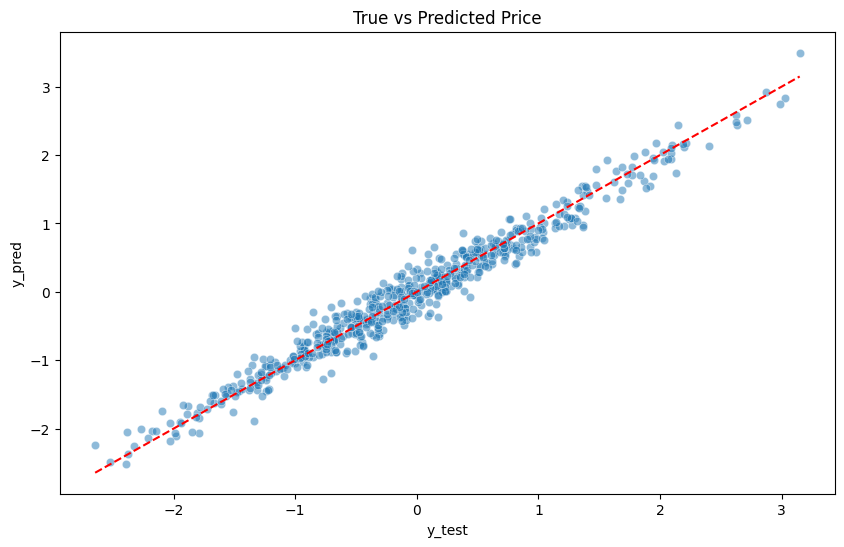

In [27]:
# 然后再画图
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=result, x='y_test', y='y_pred', alpha=0.5)
# 画一条 y=x 的红色对角线作为参考
plt.plot([result['y_test'].min(), result['y_test'].max()], 
         [result['y_test'].min(), result['y_test'].max()], 
         color='red', linestyle='--')
plt.title("True vs Predicted Price")
plt.show()

In [28]:
# ==========================================
# 方案 B: 分而治之 (Separate Models)
# ==========================================
import numpy as np

# 1. 准备容器存放预测结果
y_pred_total = []
y_true_total = []

# 2. 遍历每个 Cluster (0, 1, 2)
# 需要用 X_train_enhanced/test 里的 cluster_0/1/2 列
clusters = ['cluster_0', 'cluster_1', 'cluster_2']

for col in clusters:
    # 筛选出属于当前 Cluster 的数据 indices
    # 注意：我们的 One-Hot 编码是在 Pandas DataFrame 里的 True/False 或者 0/1
    mask_train = X_train_enhanced[col] == 1  # 或者是 == True
    mask_test = X_test_enhanced[col] == 1
    
    # 根据 mask 切分数据
    X_train_sub = X_train_enhanced[mask_train]
    y_train_sub = y_reg_train[mask_train]
    
    X_test_sub = X_test_enhanced[mask_test]
    y_test_sub = y_reg_test[mask_test]
    
    # 必须要有训练数据才能建模
    if len(X_train_sub) > 0:
        # 训练专属模型
        model_sub = LinearRegression()
        model_sub.fit(X_train_sub, y_train_sub)
        
        # 预测这个小组的测试集
        if len(X_test_sub) > 0:
            y_pred_sub = model_sub.predict(X_test_sub)
            
            # 收集结果 (用于最后算总账)
            # 注意：extend用于列表拼接，如果是numpy array需要注意转换
            y_pred_total.extend(list(y_pred_sub))
            y_true_total.extend(list(y_test_sub))
            
            print(f"Cluster [{col}] M[目标业务]: {mean_absolute_error(y_test_sub, y_pred_sub):.4f}")

# 3. 算总账 (把分散的结果重新聚合)
print("-" * 30)
if len(y_true_total) > 0:
    print(f"Separate Models Global M[目标业务]: {mean_absolute_error(y_true_total, y_pred_total):.4f}")
else:
    print("Warning: No predictions made. Check cluster column names.")

Cluster [cluster_0] M[目标业务]: 0.1417
Cluster [cluster_1] M[目标业务]: 0.1486
Cluster [cluster_2] M[目标业务]: 0.1607
------------------------------
Separate Models Global M[目标业务]: 0.1493


---

## 🔒 参考答案 (Solution)
*完成后再点开对比*

In [ ]:
# 1. EDA
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# 2. Split
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Linear Model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(f"Linear Regression M[目标业务]: {mean_absolute_error(y_test, y_pred_lr):.2f} 万")
print(f"Linear Regression R2: {r2_score(y_test, y_pred_lr):.4f}")

# 4. XGBoost Model
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print(f"XGBoost M[目标业务]: {mean_absolute_error(y_test, y_pred_xgb):.2f} 万")

# 5. Plot True vs Pred
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # 对角线
plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.title('Prediction Accuracy')
plt.show()